## FIRST SoftMax Regression

### 1. Подключаем необходимые библитеки и генерируем датасет

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [2]:
X, y = make_blobs(n_samples = 5000, centers = 4)

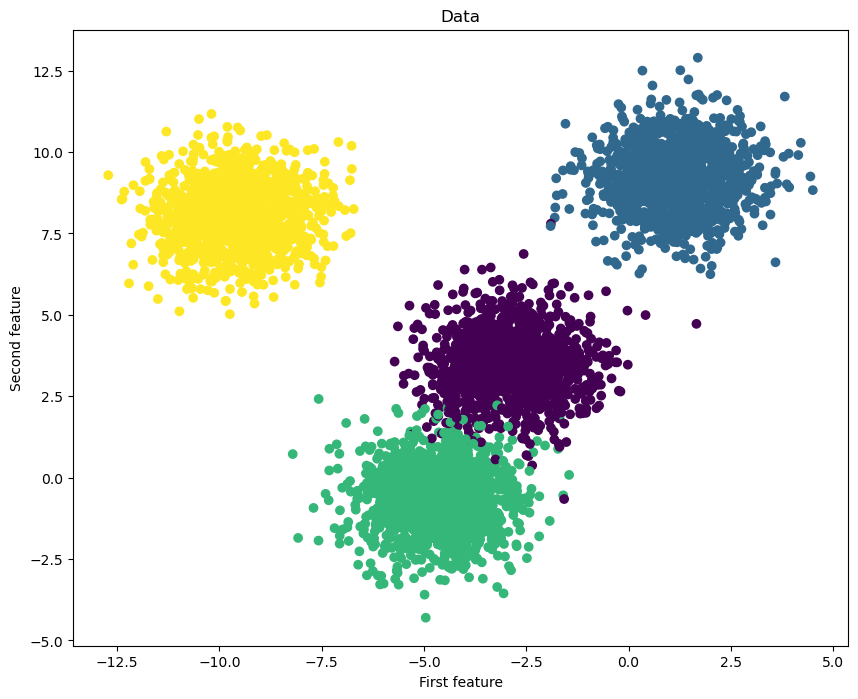

In [3]:
fig = plt.figure(figsize = (10, 8))
plt.scatter(X[:,0], X[:,1], c = y)
plt.title("Data")
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()

#### 1.1 Делим исходный датасет на тренировочный и тестовый выборки

In [4]:
y = np.vstack(y)
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3750, 2), (1250, 2), (3750, 1), (1250, 1))

### 2. Создаем собственный класс SoftmaxRegres для задачи многомерной логистической регрессии

In [5]:
class SoftmaxRegres:
    def _init_(model):
        pass

    def training(model, X, y, count_class, cost_iter = 0.01, count_iter = 700):
        model.weights = np.zeros((X.shape[1], count_class))
        model.bias = np.zeros(count_class).reshape(1, count_class)
        model.classes = count_class
        costs = []
        model.Y = np.zeros((X.shape[0], model.classes))
        model.Y[np.arange(X.shape[0]), np.hstack(y)] = 1

        for i in range(count_iter):
            costs.append(model.funcloss(X))

            if i % 100 == 0:
                print(f"Cost on {i} iterations is {costs[-1]}")

            dJ_dw = (1 / X.shape[0]) * np.dot(X.T, (model.softmax(X) - model.Y))
            dJ_db = (1 / X.shape[0]) * np.sum(model.softmax(X) - model.Y, axis = 0)

            model.weights = model.weights - cost_iter * dJ_dw
            model.bias = model.bias - cost_iter * dJ_db

        return model.weights, model.bias, costs
                
    def softmax(model, X):
        score = np.dot(X, model.weights) + model.bias
        return np.exp(score) / np.vstack(np.sum(np.exp(score), axis = 1, keepdims=True))

    def funcloss(model, X):
        return (-1 / X.shape[0]) * np.sum(model.Y * np.log(model.softmax(X)))

    def predict(model, X):
        return np.vstack(np.argmax(model.softmax(X), axis = 1))

#### 2.1 Обучаем нашу модель созданным классом 

In [6]:
model = SoftmaxRegres()
weights, bias, costs = model.training(X_train, y_train, 4, 0.21, 901)
weights, bias

Cost on 0 iterations is 1.3862943611198906
Cost on 100 iterations is 0.1487671748845662
Cost on 200 iterations is 0.0985599044168093
Cost on 300 iterations is 0.07715654512150925
Cost on 400 iterations is 0.06529523257451296
Cost on 500 iterations is 0.0577466308268266
Cost on 600 iterations is 0.05251125092685746
Cost on 700 iterations is 0.04866104453010239
Cost on 800 iterations is 0.0457066546514473
Cost on 900 iterations is 0.04336549946835937


(array([[ 0.2468188 ,  2.253699  , -1.63362532, -0.86689248],
        [ 0.43412944,  1.43601459, -2.44557917,  0.57543515]]),
 array([[ 3.70276903, -0.57741687,  0.43487631, -3.56022847]]))

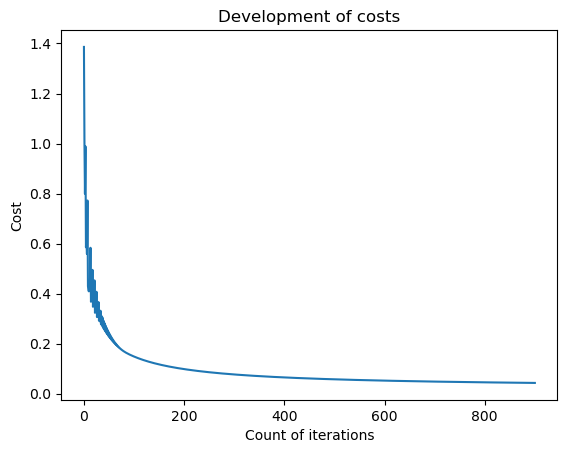

In [7]:
plt.plot(np.arange(901), costs)
plt.title("Development of costs")
plt.xlabel("Count of iterations")
plt.ylabel("Cost")
plt.show()

#### 2.2 Рассчитываем точность предсказаний нашей модели на всём датасете

In [8]:
print(f"Accuracy of model on train data is {(1 / X_train.shape[0]) * np.sum(model.predict(X_train) == y_train) * 100} %")
print(f"Accuracy of model on test data is {(1 / X_test.shape[0]) * np.sum(model.predict(X_test) == y_test) * 100} %")

Accuracy of model on train data is 99.2 %
Accuracy of model on test data is 99.2 %


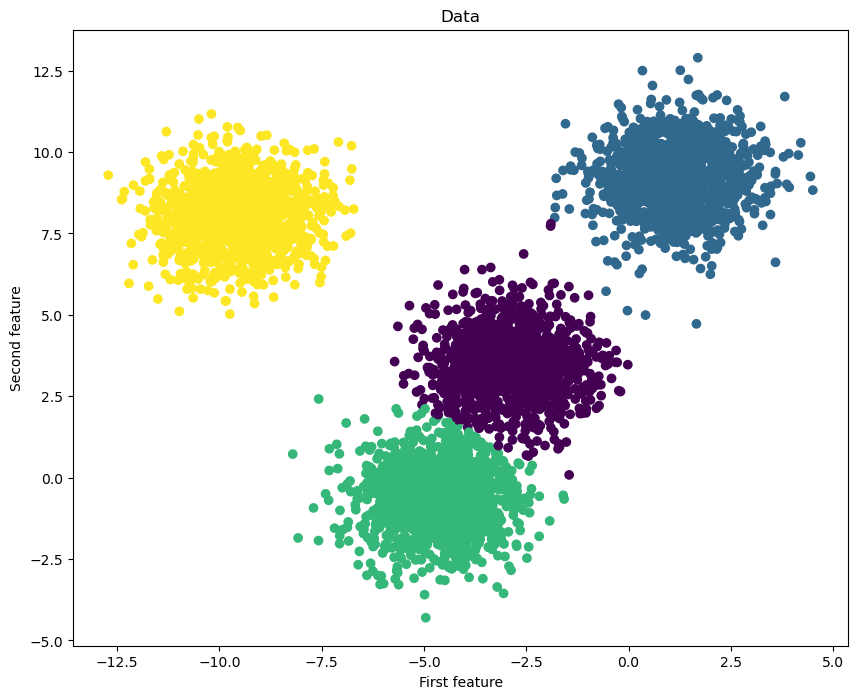

In [9]:
fig = plt.figure(figsize = (10, 8))
plt.scatter(X[:, 0], X[:, 1], c = model.predict(X))
##plt.plot(R, (-weights[0][0]/weights[1][0]) * (np.random.rand(700) * 8 - 10) + (-bias[0][0]/weights[1][0]))
plt.title("Data")
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()

### 3. Обучаем вторую модель при помощи библиотеки **sklearn**

In [10]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


sgd = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    learning_rate='optimal',
    eta0=0.01,
    max_iter=1000,
    tol=1e-3,
    shuffle=True,
    random_state=42,
    verbose=0,
    n_jobs=None
)

sgd.fit(X_train_scaled, y_train)

y_pred = sgd.predict(X_test_scaled)
score = sgd.score(X_test_scaled, y_test)

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


#### 3.1 Рассчитываем точность второй построенной модели

In [12]:
print(f"Accuracy of model on train data is {(1 / X_train.shape[0]) * np.sum(np.vstack(sgd.predict(X_train_scaled)) == y_train) * 100} %")
print(f"Accuracy of model on test data is {(1 / X_test.shape[0]) * np.sum(np.vstack(y_pred) == y_test) * 100} %")

Accuracy of model on train data is 99.2 %
Accuracy of model on test data is 99.36 %


Таким образом, обучив модель собственным классом и силами библиотеки **sklearn**, можем видеть видеть, что на тестовом наборе данных (что больше интересует чем на тренировочном) модели предсказывают за малым отличием абсолютно идентично, что говорит нам о достигнутом успехе в написании собственного класса для задачи многомерной классификации с функцией SoftMax в качестве функции-активации и кросс-энтропией в качестве функции потерь